<a href="https://colab.research.google.com/github/Yelmi95/IA_Dataset/blob/main/lab7_aprendizaje_FASHION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML - Aprendizaje No Supervisado
**Laboratorio 7** | Dataset: Fashion Product Images (Small) — Kaggle

Nombre: Yulitza Alcibia Miranda

En la mayoría de los casos, nuestros datos no vienen con etiquetas. Etiquetarlos manualmente puede ser costoso y llevar mucho tiempo. Por eso existen técnicas de aprendizaje no supervisado (*Unsupervised Learning*), que nos permiten analizar y descubrir patrones en los datos sin necesidad de etiquetas previas.

## Clustering

El *Clustering* es una técnica popular de aprendizaje no supervisado que agrupa datos similares en conjuntos llamados *clusters*. Esto ayuda a descubrir patrones y segmentar información, siendo útil en áreas como la segmentación de clientes, análisis de datos, reducción de dimensiones, detección de anomalías y motores de búsqueda.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import random

n_centers = random.randint(2, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-15, 15, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

# Normalización con MinMaxScaler: garantiza distancias euclidianas comparables
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Se generaron {n_centers} centros")
print("Coordenadas de los centroides:")
print(blob_centers)

Se generaron 13 centros
Coordenadas de los centroides:
[[ -1.4390409    2.51353683]
 [  3.04152198 -12.14820061]
 [-13.35778907   3.22120935]
 [ 13.61299263  -9.75755965]
 [ -3.15237475   3.82452409]
 [ -5.20922453 -11.28254263]
 [-14.38383668 -14.80291288]
 [ -5.88959567  -0.05330946]
 [ -8.39037226  -7.92309015]
 [  0.25642753  -7.9517469 ]
 [ -3.33260679   7.88978718]
 [ 12.54165823   5.44665482]
 [ 14.62474577  -0.54391665]]


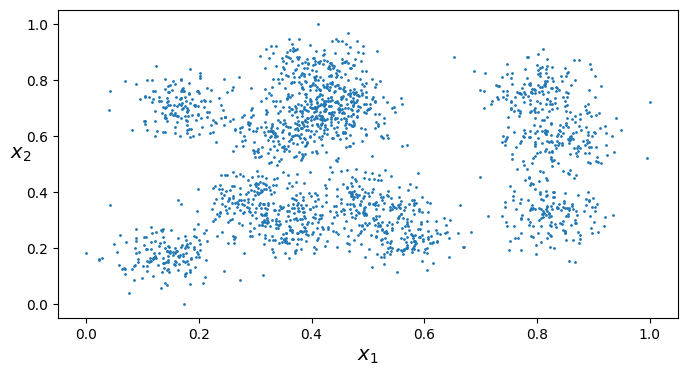

In [ ]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X_scaled)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.

In [ ]:
k = n_centers
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_scaled)
y_pred

array([7, 5, 0, ..., 1, 9, 6], dtype=int32)

In [ ]:
kmeans.cluster_centers_

array([[0.35548598, 0.59045559],
       [0.55398836, 0.23633412],
       [0.80038396, 0.76629973],
       [0.12717751, 0.13895188],
       [0.80991404, 0.39617091],
       [0.17243559, 0.70522881],
       [0.32899589, 0.32725151],
       [0.50088145, 0.37480417],
       [0.84300514, 0.58930366],
       [0.40680781, 0.84457421],
       [0.44252124, 0.69653301],
       [0.17113045, 0.22385731],
       [0.83256465, 0.28492375]])

In [ ]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
X_new_scaled = scaler.transform(X_new)
kmeans.predict(X_new_scaled)

array([10, 10, 10, 10], dtype=int32)

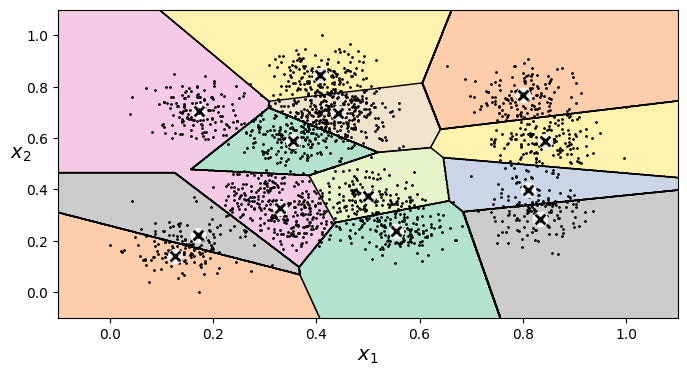

In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=2)

def plot_centroids(centroids, weights=None, circle_color="w", cross_color="k"):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker="o", s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker="x", s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors="k")
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X_scaled)
plt.show()

En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [ ]:
kmeans.transform(X_new_scaled)

array([[0.15347389, 0.4293397 , 0.32609096, 0.63683819, 0.41407112,
        0.32231167, 0.37142361, 0.28647633, 0.358557  , 0.20213829,
        0.06060773, 0.54220508, 0.50765278],
       [0.22011689, 0.42491646, 0.25877067, 0.68076551, 0.36153162,
        0.39398681, 0.40826399, 0.29319271, 0.28815444, 0.24154319,
        0.12648057, 0.58780583, 0.46226555],
       [0.11857864, 0.47345255, 0.38840959, 0.62402467, 0.48880844,
        0.24750268, 0.37413628, 0.32580658, 0.4353898 , 0.1548146 ,
        0.02386857, 0.52842262, 0.57874609],
       [0.10660118, 0.45949874, 0.39152272, 0.6111876 , 0.48018125,
        0.24880847, 0.36001331, 0.31171705, 0.43224255, 0.16934274,
        0.03105378, 0.51560508, 0.56863432]])

Este algoritmo comienza eligiendo algunos puntos al azar como centroides. Luego, en cada paso, agrupa las muestras según el centroide más cercano y actualiza la posición de cada centroide calculando el promedio de los puntos que le han tocado. Así, poco a poco, los grupos y sus centros se van ajustando hasta que todo queda bien repartido.

In [ ]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1, algorithm="elkan", max_iter=3, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1, algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1, algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X_scaled)
kmeans_iter2.fit(X_scaled)
kmeans_iter3.fit(X_scaled)

KMeans(algorithm='elkan', max_iter=3, n_clusters=13, n_init=1, random_state=5)

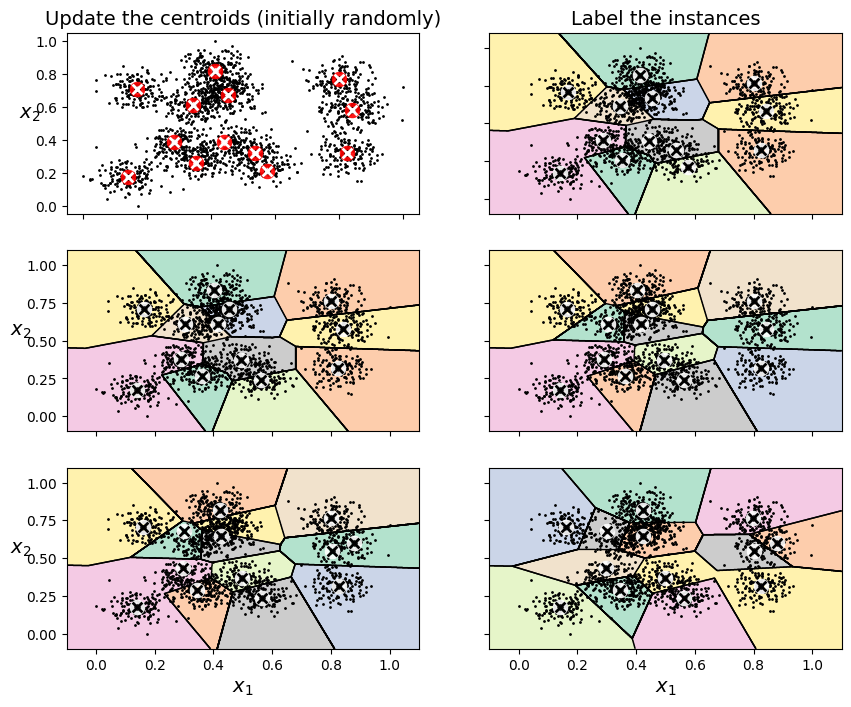

In [ ]:
plt.figure(figsize=(10, 8))
plt.subplot(321)
plot_data(X_scaled)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color="r", cross_color="w")
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)
plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X_scaled, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)
plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X_scaled, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)
plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X_scaled, show_xlabels=False, show_ylabels=False)
plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X_scaled, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)
plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X_scaled, show_ylabels=False)
plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

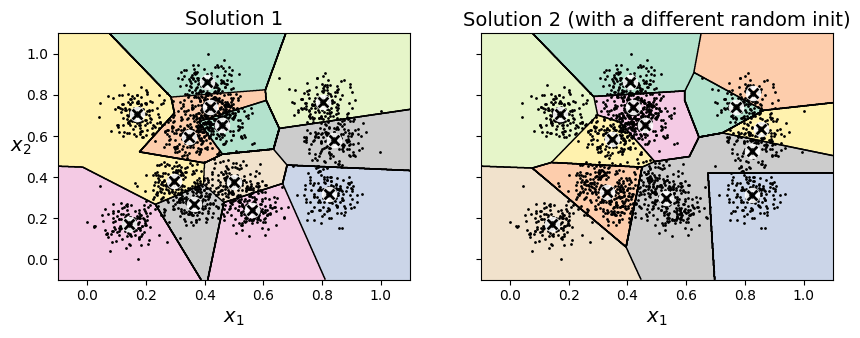

In [ ]:
def plot_clusterer_comparison(c1, c2, X, t1=None, t2=None):
    c1.fit(X)
    c2.fit(X)
    plt.figure(figsize=(10, 3.2))
    plt.subplot(121)
    plot_decision_boundaries(c1, X)
    if t1: plt.title(t1, fontsize=14)
    plt.subplot(122)
    plot_decision_boundaries(c2, X, show_ylabels=False)
    if t2: plt.title(t2, fontsize=14)

kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1, algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1, algorithm="elkan", random_state=19)
plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X_scaled,
                          "Solution 1", "Solution 2 (with a different random init)")
plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en *Scikit-Learn*.

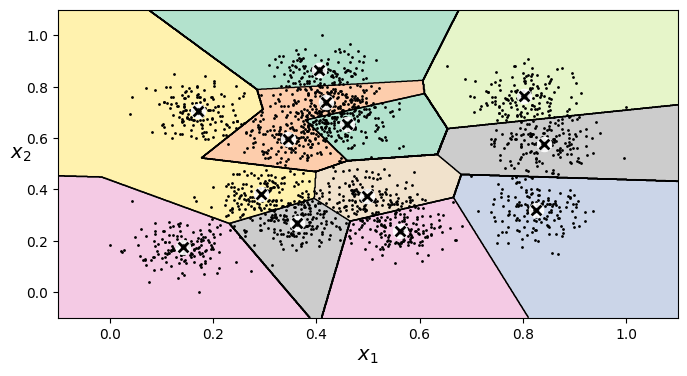

In [ ]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10, algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X_scaled)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X_scaled)
plt.show()

Existen varias formas de mejorar el algoritmo *K-Means*. Por ejemplo, hay versiones más rápidas (como la que usa *Scikit-Learn* por defecto) y también está el *mini-batch K-Means*, ideal cuando el conjunto de datos es tan grande que no cabe en memoria.

In [ ]:
from sklearn.cluster import MiniBatchKMeans

def load_next_batch(batch_size):
    return X_scaled[np.random.choice(len(X_scaled), batch_size, replace=False)]

k_mb = 13
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 1300
evaluate_on_last_n_iters = 10
best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_mb, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)
    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_
    if best_kmeans is None or minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_:
        best_kmeans = minibatch_kmeans

best_kmeans.score(X_scaled)

-9.296994876947274

El algoritmo de mini-batch K-Means funciona mucho más rápido que el K-Means tradicional, aunque normalmente sacrifica algo de precisión a cambio de esa velocidad.

### Encontrando el número óptimo de grupos

El número de clusters es un parámetro clave que debemos elegir al usar estos modelos. Cuando no tenemos etiquetas, no sabemos cuál es el valor ideal, así que probamos varios y usamos métricas para decidir. Una de las más útiles es el *silhouette score*, que mide qué tan bien está cada muestra dentro de su grupo: valores cercanos a 1 indican que la muestra está bien agrupada, cerca de 0 que está en el límite entre grupos, y negativos que probablemente está en el grupo equivocado.

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, kmeans.labels_)

np.float64(0.40378935348334316)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

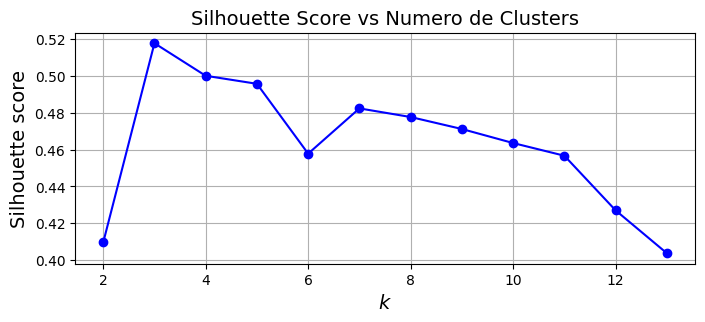

In [ ]:
max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=kk, random_state=42).fit(X_scaled) for kk in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X_scaled, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Numero de Clusters", fontsize=14)
plt.grid(True)
plt.show()

### ELBOW METHOD
Calcula la inercia para distintos valores de k

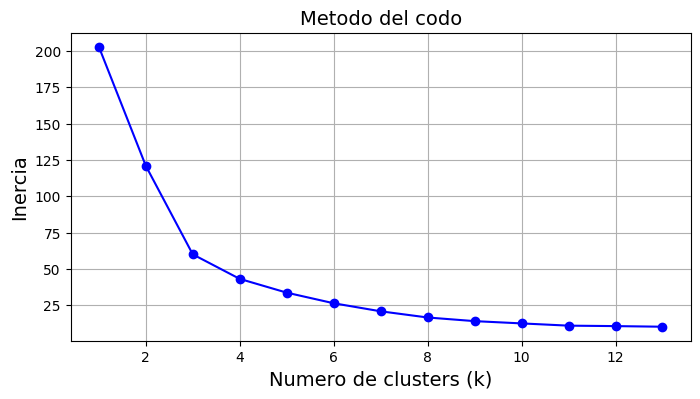

In [ ]:
inertias = []
K_range = range(1, max_k + 1)

for kk in K_range:
    km_temp = KMeans(n_clusters=kk, random_state=42).fit(X_scaled)
    inertias.append(km_temp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, "bo-")
plt.xlabel("Numero de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Metodo del codo", fontsize=14)
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

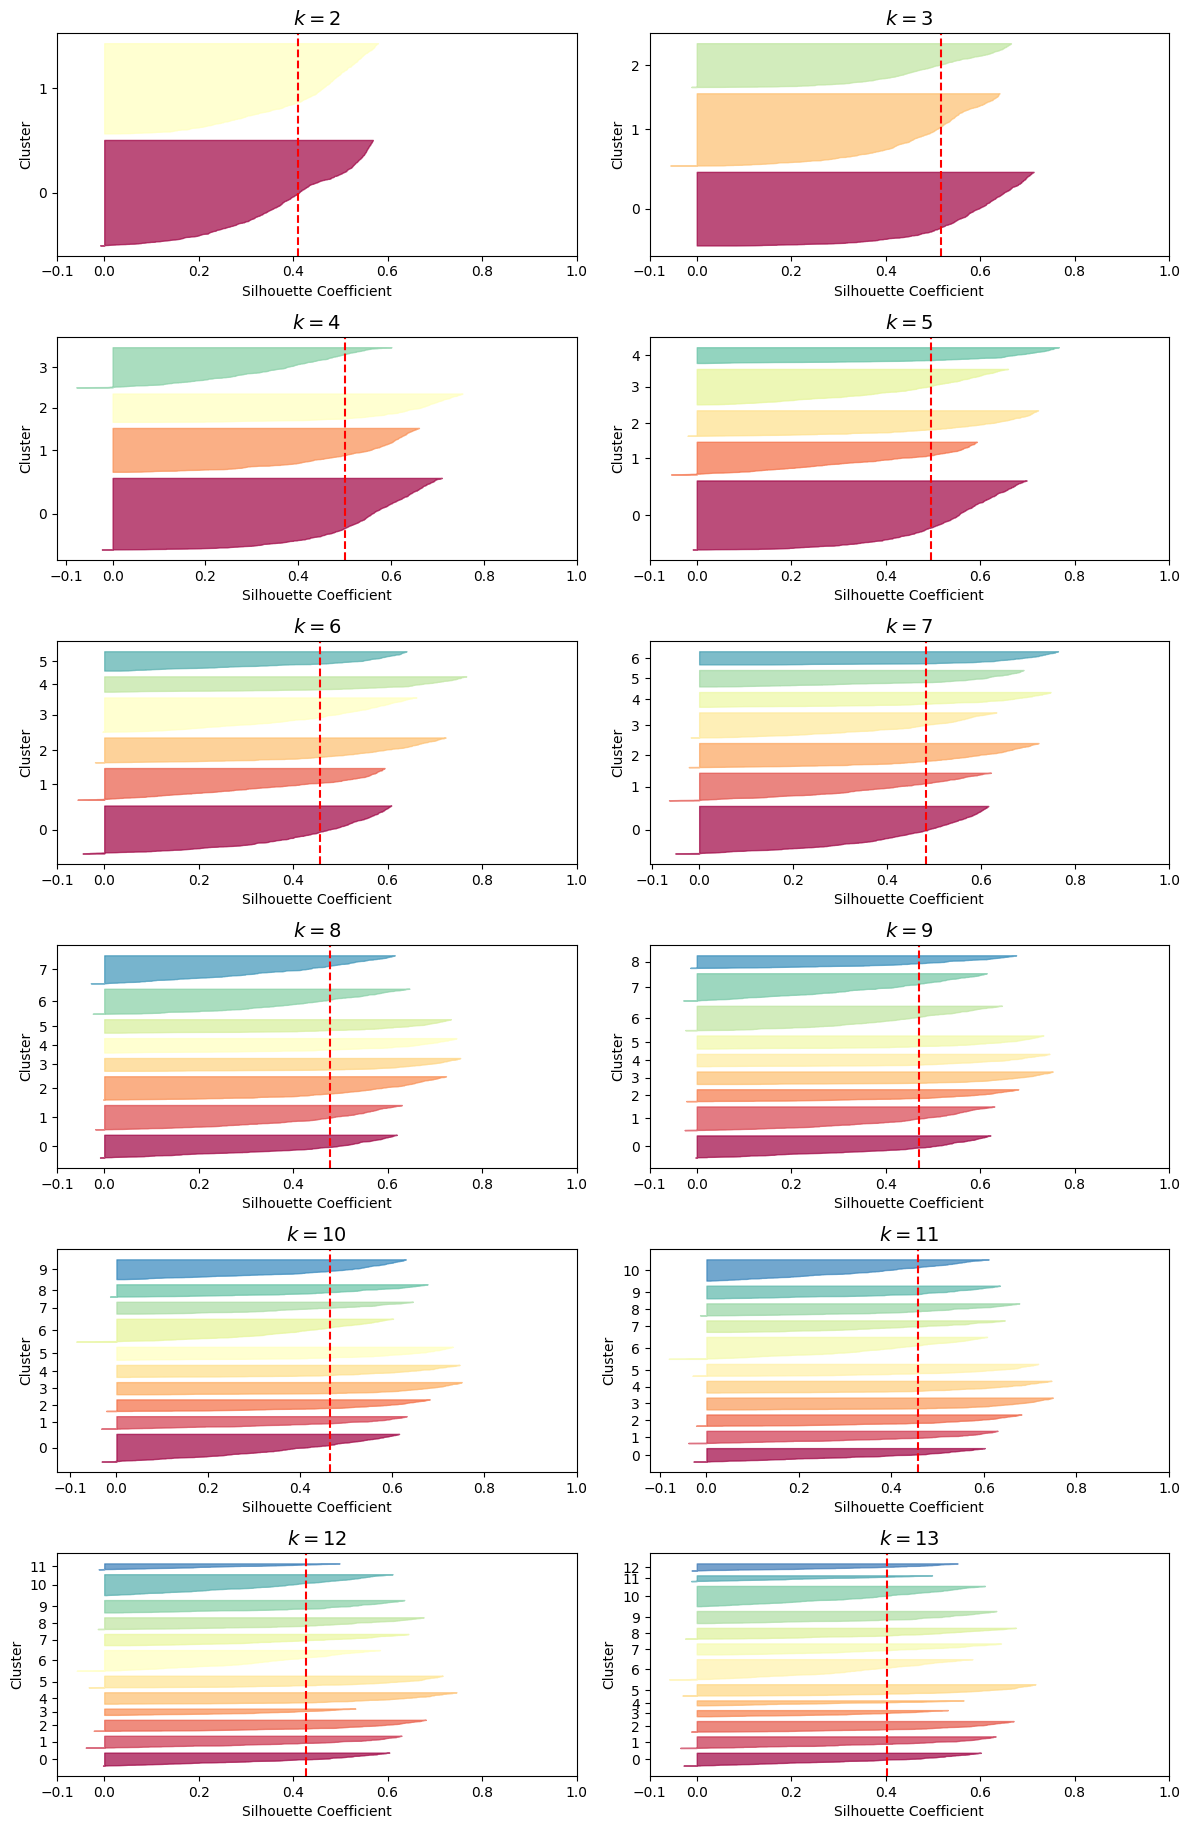

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))

for plot_idx, kk in enumerate(range(2, n_ks + 1)):
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)
    y_pred_sil = kmeans_per_k[kk - 1].labels_
    sil_coeffs = silhouette_samples(X_scaled, y_pred_sil)
    padding = len(X_scaled) // 30
    pos = padding
    ticks = []
    for i in range(kk):
        coeffs = sil_coeffs[y_pred_sil == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / kk)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding
    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(kk)))
    plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    if kk - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[kk - 2], color="red", linestyle="--")
    plt.title(f"$k={kk}$", fontsize=14)

plt.tight_layout()
plt.show()

## K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado, también conocido como *Semi-supervised Learning*, reune tecnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta seccion veremos, de forma practica y sencilla, como aplicar este enfoque usando el dataset **Fashion Product Images (Small)** de Kaggle y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.

### Exploracion del dataset: cuantas clases tiene originalmente?

### Dataset: Fashion Product Images (Small)

El dataset utilizado en este laboratorio es **Fashion Product Images (Small)**,
disponible públicamente en Kaggle. Contiene imágenes de productos de moda de un
catálogo de comercio electrónico, acompañadas de metadatos detallados en un archivo
`styles.csv` que incluye información como la categoría del producto, género, color
y temporada.

En su forma original el dataset cuenta con **44,446 registros** distribuidos en
aproximadamente **142 categorías** diferentes (`articleType`), lo que lo hace
extremadamente diverso pero también muy desbalanceado — algunas categorías tienen
miles de imágenes mientras que otras apenas superan la decena.

Para este laboratorio se tomaron las siguientes decisiones de preprocesamiento:

- **Selección de 15 clases**: se eligieron las categorías con mayor representación
  y variedad visual: *Watches, Handbags, Sunglasses, Wallets, Belts, Backpacks,
  Socks, Perfume and Body Mist, Tshirts, Shorts, Trousers, Briefs, Sports Shoes,
  Heels y Shirts*.

- **Balanceo por undersampling**: dado que el dataset original está desbalanceado,
  se limitó cada clase a **750 imágenes**, obteniendo un total de **11,250 imágenes**
  distribuidas de forma uniforme entre las 15 clases.

- **Escala de grises 32×32**: cada imagen se convirtió a escala de grises y se
  redimensionó a 32×32 píxeles. Esta es una decisión estratégica — sin aplicar
  reducción de dimensionalidad como PCA, trabajar con color implicaría vectores de
  3,072 dimensiones (32×32×3). Con escala de grises se reduce a **1,024 dimensiones**
  (32×32×1), aligerando la carga computacional sin perder la información de forma
  y silueta de cada producto, que es lo más relevante para distinguir las categorías.

- **Normalización con MinMaxScaler**: los valores de píxel se normalizaron al rango
  [0, 1] para garantizar que las distancias euclidianas entre imágenes sean
  comparables, condición necesaria para que K-Means funcione correctamente.

Las etiquetas no se obtienen de las imágenes sino del archivo `styles.csv`, que
relaciona cada imagen (identificada por su `id`) con su categoría correspondiente.
Este archivo actúa como base de datos de metadatos del catálogo.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile, io
import pandas as pd

RUTA_ZIP = "/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/archive (12).zip"
zf = zipfile.ZipFile(RUTA_ZIP, "r")

with zf.open("styles.csv") as f:
    df_all = pd.read_csv(f, on_bad_lines="skip")

print("=" * 55)
print("  EXPLORACION COMPLETA DEL DATASET FASHION")
print("=" * 55)
print(f"\nTotal de imagenes en el dataset: {len(df_all)}")
print(f"\nTODAS las categorias ({df_all['articleType'].nunique()} clases en total):")
print(df_all["articleType"].value_counts().to_string())

Mounted at /content/drive
  EXPLORACION COMPLETA DEL DATASET FASHION

Total de imagenes en el dataset: 44424

TODAS las categorias (143 clases en total):
articleType
Tshirts                      7067
Shirts                       3217
Casual Shoes                 2845
Watches                      2542
Sports Shoes                 2036
Kurtas                       1844
Tops                         1762
Handbags                     1759
Heels                        1323
Sunglasses                   1073
Wallets                       936
Flip Flops                    914
Sandals                       897
Briefs                        849
Belts                         813
Backpacks                     724
Socks                         686
Formal Shoes                  637
Perfume and Body Mist         613
Jeans                         609
Shorts                        547
Trousers                      530
Flats                         500
Bra                           477
Dresses           

Se seleccionan las **15 clases** con mayor representacion (minimo 500 imagenes cada una). Se aplica *undersampling* a 500 imagenes por clase para corregir el desbalance original del dataset.

In [ ]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

CLASES_SELECCIONADAS = [
    "Watches", "Handbags", "Sunglasses", "Wallets",
    "Belts", "Backpacks", "Socks", "Perfume and Body Mist",
    "Tshirts", "Shorts", "Trousers", "Briefs",
    "Sports Shoes", "Heels", "Shirts"
]

with zf.open("styles.csv") as f:
    df = pd.read_csv(f, on_bad_lines="skip")

df = df[df["articleType"].isin(CLASES_SELECCIONADAS)].dropna(subset=["id","articleType"])
df["id"] = df["id"].astype(int)

N_POR_CLASE = 750
np.random.seed(42)
df_bal = pd.concat([
    df[df["articleType"]==c].sample(n=min(N_POR_CLASE, len(df[df["articleType"]==c])), random_state=42)
    for c in CLASES_SELECCIONADAS
]).reset_index(drop=True)

print(f"Dataset balanceado: {len(df_bal)} imagenes ({N_POR_CLASE} por clase)")
print(df_bal["articleType"].value_counts())

Dataset balanceado: 10600 imagenes (750 por clase)
articleType
Watches                  750
Handbags                 750
Sunglasses               750
Wallets                  750
Belts                    750
Heels                    750
Tshirts                  750
Shirts                   750
Briefs                   750
Sports Shoes             750
Backpacks                724
Socks                    686
Perfume and Body Mist    613
Shorts                   547
Trousers                 530
Name: count, dtype: int64


In [ ]:
le = LabelEncoder()
le.fit(CLASES_SELECCIONADAS)
nombres_zip = set(zf.namelist())

train_images_list, train_labels_list, imagenes_gris_list = [], [], []

for _, row in df_bal.iterrows():
    img_id, clase = int(row["id"]), row["articleType"]
    for ext in [".jpg", ".jpeg", ".png"]:
        ruta = f"images/{img_id}{ext}"
        if ruta in nombres_zip:
            try:
                with zf.open(ruta) as f:
                    img = Image.open(io.BytesIO(f.read())).convert("L").resize((32,32), Image.LANCZOS)
                    arr = np.array(img, dtype=np.float32)
                    imagenes_gris_list.append(arr)
                    train_images_list.append(arr.flatten())
                    train_labels_list.append(le.transform([clase])[0])
            except:
                pass
            break

train_images_arr = np.array(train_images_list)
train_labels_arr = np.array(train_labels_list, dtype=np.int64)
imagenes_gris_arr = np.array(imagenes_gris_list)

print("Imagenes cargadas:", train_images_arr.shape)
print("Etiquetas:", train_labels_arr.shape)
print("Clases:", list(le.classes_))

Imagenes cargadas: (10600, 1024)
Etiquetas: (10600,)
Clases: [np.str_('Backpacks'), np.str_('Belts'), np.str_('Briefs'), np.str_('Handbags'), np.str_('Heels'), np.str_('Perfume and Body Mist'), np.str_('Shirts'), np.str_('Shorts'), np.str_('Socks'), np.str_('Sports Shoes'), np.str_('Sunglasses'), np.str_('Trousers'), np.str_('Tshirts'), np.str_('Wallets'), np.str_('Watches')]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    train_images_arr, train_labels_arr, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (7950, 1024)
y_train shape: (7950,)
X_test shape:  (2650, 1024)
y_test shape:  (2650,)


Imagina que tenemos un conjunto de imagenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a que clase pertenece cada imagen, ni cuantas clases diferentes hay. En este caso, una buena estrategia seria aplicar el algoritmo K-Means y pedirle que agrupe las imagenes en, por ejemplo, 50 grupos. Asi, podriamos identificar cuales son las imagenes mas representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

In [ ]:
from sklearn.cluster import KMeans

k = 20
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

In [ ]:
print(X_digits_dist.shape)
print(X_digits_dist)

(7950, 15)
[[2657.5728  2750.91    2963.949   ... 2725.9895  1399.1959  2436.8904 ]
 [2517.1257  1051.7125  3187.0266  ... 2799.326   1754.9553  2924.309  ]
 [2606.857   2790.8582  2510.9067  ... 2358.0537  1782.9824  1937.4365 ]
 ...
 [2440.9128   981.55615 3370.9875  ... 2774.659   1904.9252  3118.6704 ]
 [2318.8425  2170.2273  2727.1519  ... 2372.9385  1031.9801  2218.887  ]
 [2694.4956  3267.3818  2488.9282  ... 2608.053   3039.201   2519.3103 ]]


In [ ]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

In [ ]:
print(X_representative_digits.shape)
print(X_representative_digits)

(20, 1024)
[[176. 178. 179. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 ...
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]
 [255. 255. 255. ... 255. 255. 255.]]


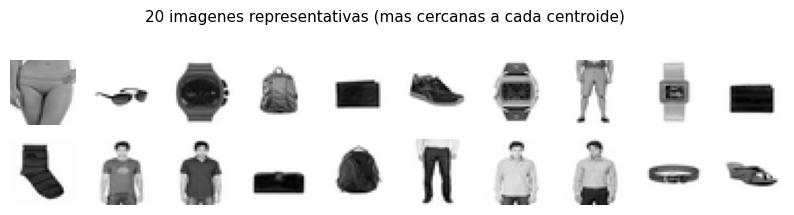

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(32, 32), cmap="gray")
    plt.axis("off")
plt.suptitle("20 imagenes representativas (mas cercanas a cada centroide)", fontsize=11)
plt.show()

El siguiente paso consiste en anotar manualmente estas etiquetas (aqui haremos trampas ya que disponemos de dichas etiquetas).

In [ ]:
y_representative_digits = y_train[idxs]

Y entrenaremos un clasificador usando estas imagenes representativas.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                               max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
log_reg2.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 400 ms, sys: 3.9 ms, total: 404 ms
Wall time: 216 ms


0.54

Como puedes observar hemos obtenido cierta precision habiendo anotado simplemente 20 imagenes, pero aquellas mas representativas. Entrenar el mismo modelo con 20 imagenes aleatorias nos daria peores resultados.

In [ ]:
idxs_random = np.random.choice(len(X_train), 20, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs",
                              max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs_random], y_train[idxs_random])
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 864 ms, sys: 1.88 ms, total: 866 ms
Wall time: 1.39 s


0.4033962264150943

A veces, al entrenar modelos de Machine Learning, no importa tanto tener muchos datos, sino que sean los mas utiles y representativos.
Una vez que hemos entrenado un clasificador con las imagenes mas representativas, podemos aprovecharlo para etiquetar automaticamente el resto del conjunto. Para ello, asignamos a todas las imagenes de cada grupo la misma etiqueta que le dimos a su representante.

In [ ]:
y_train_propagated = np.empty(len(X_train))
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [ ]:
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                               max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
log_reg3.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 30.7 s, sys: 33.3 ms, total: 30.7 s
Wall time: 18.2 s


0.5335849056603773

A veces, al intentar mejorar el modelo anadiendo mas datos etiquetados automaticamente, el resultado puede ser peor. Esto ocurre porque no todas las imagenes quedan bien agrupadas y se introduce ruido en el entrenamiento. Para evitarlo, podemos limitar el etiquetado solo a las muestras que esten mas cerca de los representantes de cada grupo, o bien recurrir a tecnicas de aprendizaje activo para seleccionar mejor que ejemplos anotar.

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteracion nuevas muestras al dataset focalizando en ejemplos en los que el modelo tenga mas problemas.

In [ ]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.99877425, 0.99923286, 0.99926641, 0.9994279 , 0.99943583,
       0.99945154, 0.99949164, 0.99950994, 0.99951017, 0.99951209])

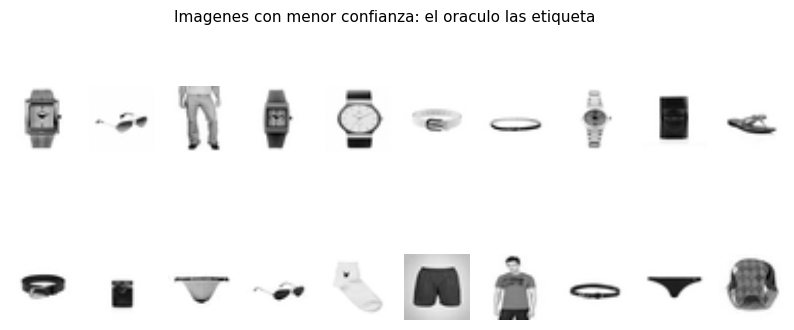

In [ ]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(32, 32), cmap="gray", interpolation="bilinear")
    plt.axis("off")
plt.suptitle("Imagenes con menor confianza: el oraculo las etiqueta", fontsize=11)
plt.show()

In [ ]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([14, 10, 11, 14, 14,  1,  1, 14,  5,  4,  1,  5,  2, 10,  8,  7, 12,
        1,  2,  0])

In [ ]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [ ]:
log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                               max_iter=5000, random_state=42)
%time log_reg5.fit(X_train[:1000], y_train2)
log_reg5.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 34.6 s, sys: 65.2 ms, total: 34.7 s
Wall time: 22.3 s


0.5475471698113208

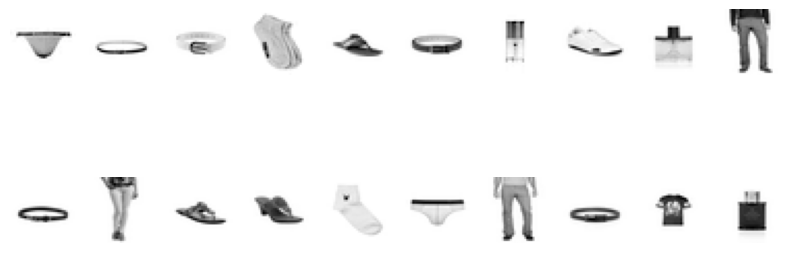

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Score ronda 2: 0.549811320754717


In [ ]:
# ── RONDA 2 ──
probas2 = log_reg5.predict_proba(X_train[:1000])
labels_ixs2 = np.argmax(probas2, axis=1)
labels2 = np.array([proba[ix] for proba, ix in zip(probas2, labels_ixs2)])
sorted_ixs2 = np.argsort(labels2)

# Visualizar las nuevas 10 más inciertas
X_lowest2 = X_train[:1000][sorted_ixs2[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest2):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()

# El oráculo etiqueta de nuevo
y_lowest2 = y_train[:1000][sorted_ixs2[:k]]

y_train3 = y_train2.copy()
y_train3[sorted_ixs2[:k]] = y_lowest2

log_reg6 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                               max_iter=5000, random_state=42)
log_reg6.fit(X_train[:1000], y_train3)
print("Score ronda 2:", log_reg6.score(X_test, y_test))

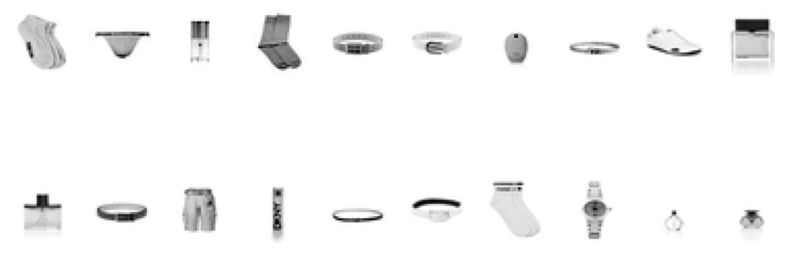

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Score ronda 3: 0.5649056603773585


In [ ]:
# ── RONDA 3 ──
probas3 = log_reg6.predict_proba(X_train[:1000])
labels_ixs3 = np.argmax(probas3, axis=1)
labels3 = np.array([proba[ix] for proba, ix in zip(probas3, labels_ixs3)])
sorted_ixs3 = np.argsort(labels3)

# Visualizar las nuevas 10 más inciertas
X_lowest3 = X_train[:1000][sorted_ixs3[:k]]
plt.figure(figsize=(10, 4))
for index, img in enumerate(X_lowest3):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()

# El oráculo etiqueta de nuevo
y_lowest3 = y_train[:1000][sorted_ixs3[:k]]

y_train4 = y_train3.copy()
y_train4[sorted_ixs3[:k]] = y_lowest3

log_reg7 = LogisticRegression(multi_class="ovr", solver="lbfgs",
                               max_iter=5000, random_state=42)
log_reg7.fit(X_train[:1000], y_train4)
print("Score ronda 3:", log_reg7.score(X_test, y_test))

In [ ]:
print("="*50)
print("  COMPARATIVA COMPLETA")
print("="*50)
print(f"  20 representativas (log_reg2): {log_reg2.score(X_test, y_test):.4f}")
print(f"  Propagación        (log_reg3): {log_reg3.score(X_test, y_test):.4f}")
print(f"  Ronda 1            (log_reg5): {log_reg5.score(X_test, y_test):.4f}")
print(f"  Ronda 2            (log_reg6): {log_reg6.score(X_test, y_test):.4f}")
print(f"  Ronda 3            (log_reg7): {log_reg7.score(X_test, y_test):.4f}")
print("="*50)

  COMPARATIVA COMPLETA
  20 representativas (log_reg2): 0.5400
  Propagación        (log_reg3): 0.5336
  Ronda 1            (log_reg5): 0.5475
  Ronda 2            (log_reg6): 0.5498
  Ronda 3            (log_reg7): 0.5649


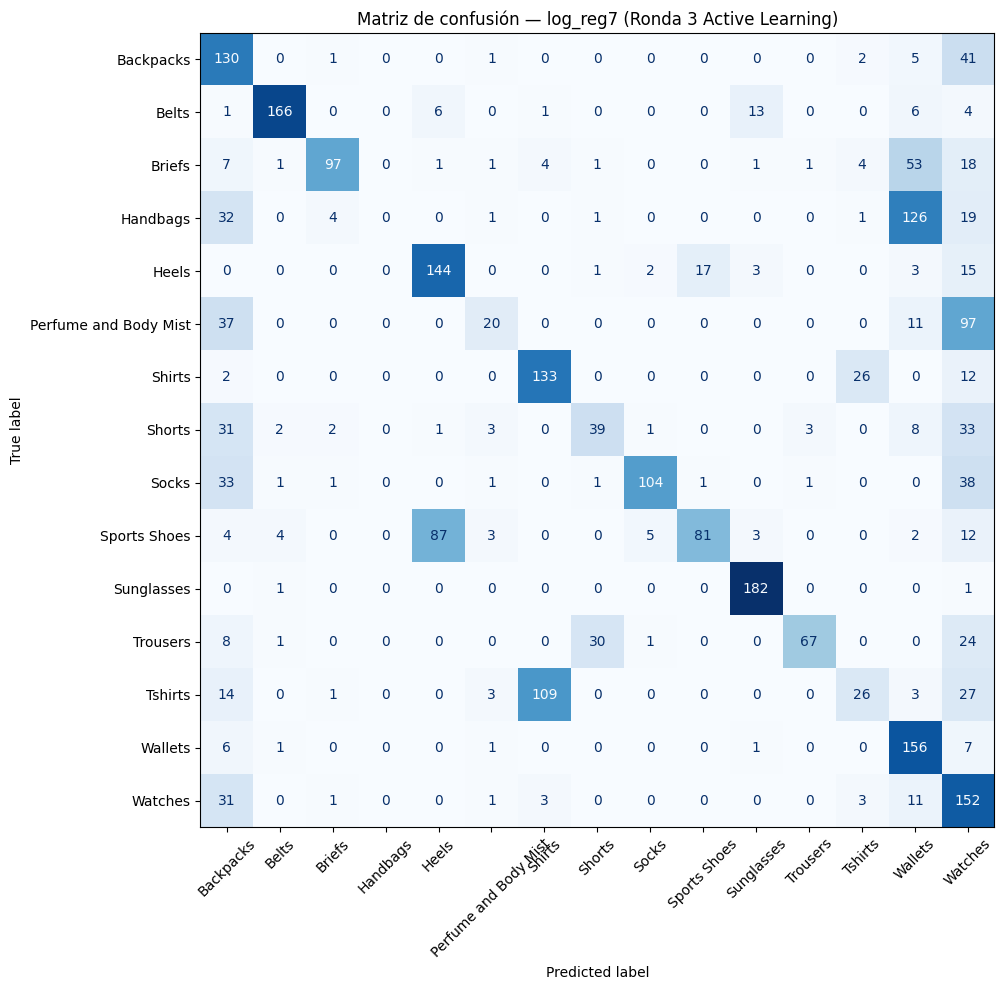

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = log_reg7.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(ax=plt.gca(), cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Matriz de confusión — log_reg7 (Ronda 3 Active Learning)", fontsize=12)
plt.tight_layout()
plt.show()